In [12]:
import pandas as pd
import pandas_ta as ta
#from neuralprophet import NeuralProphet

In [ ]:
#from neuralprophet import NeuralProphet

c:\Users\user\Documents\diplom\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing matplotlib failed. Plotting will not work.
Importing matplotlib failed. Plotting will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


In [337]:
import pandas as pd
import pandas_ta as ta


class ModelFeatures:
    def __init__(self, df: pd.DataFrame, shift: int = 0):
        """
        :param df: DataFrame с ежемесячными данными и колонками:
                  'symbol', 'Open', 'High', 'Low', 'Close', 'Volume'
        :param shift: сдвиг данных в месяцах (например, -1 — будущие значения, 1 — прошлые)
        """
        self.df = df.copy()
        self.shift = shift
        
        # Проверяем наличие необходимых колонок
        required_columns = ['symbol', 'Open', 'High', 'Low', 'Close', 'Volume']
        if not all(col in self.df.columns for col in required_columns):
            raise ValueError(f"DataFrame должен содержать колонки: {required_columns}")
        
        # Применяем сдвиг к ценам и объёму в рамках каждого символа
        self.df[['Open', 'High', 'Low', 'Close', 'Volume']] = self.df.groupby('symbol')[['Open', 'High', 'Low', 'Close', 'Volume']].shift(shift)
        
        # Удаляем строки с NaN, которые могли появиться после сдвига
        self.df = self.df.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'])

    def add_ema(self):
        """Добавляет экспоненциальные скользящие средние для ежемесячных данных (уже с учётом сдвига)"""
        def _calculate_ema(group):
            group['ema_3'] = ta.ema(group['Close'], length=3)   # 3 месяца
            group['ema_6'] = ta.ema(group['Close'], length=6)    # 6 месяцев
            group['ema_12'] = ta.ema(group['Close'], length=12)  # 1 год
            group['ema_24'] = ta.ema(group['Close'], length=24)  # 2 года
            return group
            
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_ema)
        return self

    def add_rsi(self):
        """Добавляет RSI с периодами, адаптированными для месячных данных (уже с учётом сдвига)"""
        def _calculate_rsi(group):
            group['rsi_6'] = ta.rsi(group['Close'], length=6)   # 6 месяцев
            group['rsi_12'] = ta.rsi(group['Close'], length=12)  # 1 год
            group['rsi_24'] = ta.rsi(group['Close'], length=24)  # 2 года
            return group
            
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_rsi)
        return self

    def add_macd(self):
        """Добавляет MACD с параметрами для месячных данных (уже с учётом сдвига)"""
        def _calculate_macd(group):
            macd = ta.macd(group['Close'], fast=6, slow=12, signal=9)
            group['macd_line'] = macd.iloc[:, 0]  # MACD линия
            group['macd_signal'] = macd.iloc[:, 1]  # Сигнальная линия
            group['macd_hist'] = macd.iloc[:, 2]    # Гистограмма
            return group
            
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_macd)
        return self

    def add_volatility(self):
        """Добавляет ATR с периодами для месячных данных (уже с учётом сдвига)"""
        def _calculate_atr(group):
            group['atr_6'] = ta.atr(group['High'], group['Low'], group['Close'], length=6)   # 6 месяцев
            group['atr_12'] = ta.atr(group['High'], group['Low'], group['Close'], length=12)  # 1 год
            return group
            
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_atr)
        return self

    def add_volume_indicators(self):
        """Добавляет объемные индикаторы для месячных данных (уже с учётом сдвига)"""
        def _calculate_volume_indicators(group):
            group['obv'] = ta.obv(group['Close'], group['Volume'])
            group['volume_ma_6'] = ta.sma(group['Volume'], length=6)   # 6-месячное среднее объема
            group['volume_ma_12'] = ta.sma(group['Volume'], length=12)  # 12-месячное среднее объема
            return group
                
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_volume_indicators)
        return self

    def add_momentum(self):
        """Добавляет индикаторы момента для месячных данных (уже с учётом сдвига)"""
        def _calculate_momentum(group):
            group['mom_6'] = ta.mom(group['Close'], length=6)    # 6-месячный момент
            group['mom_12'] = ta.mom(group['Close'], length=12)  # 12-месячный момент
            group['roc_6'] = ta.roc(group['Close'], length=6)     # 6-месячная скорость изменения
            group['roc_12'] = ta.roc(group['Close'], length=12)   # 12-месячная скорость изменения
            return group
            
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_momentum)
        return self

    def add_target(self, horizon_months: int = 1, target_col: str = 'target_return'):
        """
        Добавляет целевую переменную: доходность через horizon_months месяцев
        :param horizon_months: горизонт прогноза (в месяцах)
        :param target_col: название колонки с целевой переменной
        """
        def _calculate_target(group):
            group[target_col] = group['Close'].shift(-horizon_months) / group['Close'] - 1
            return group
            
        self.df = self.df.groupby('symbol', group_keys=False).apply(_calculate_target)
        return self

    def get_features(self, keep_original: bool = False):
        """
        Возвращает финальный DataFrame с признаками
        :param keep_original: если True, сохраняет оригинальные колонки (Open, High, Low, Close, Volume)
        """
        if not keep_original:
            cols_to_drop = ['Open', 'High', 'Low', 'Close', 'Volume', 'next_month_close']
            self.df = self.df.drop(columns=cols_to_drop, errors='ignore')
        
        return self.df.dropna().reset_index(drop=True)

In [338]:
df = pd.read_csv("data/sp500_ml_monthly_20250516_120505.csv")
df.drop(['Adj Close', 'month_return'], axis=1, inplace=True)
features = ModelFeatures(df, shift=3) \
    .add_ema() \
    .add_rsi() \
    .add_macd() \
    .add_volatility() \
    .add_volume_indicators() \
    .add_momentum() \
    .add_target(horizon_months=1)  # прогноз на 3 месяца вперёд

# Получаем финальный датафрейм
final_df = features.get_features(keep_original=False)

C:\Users\user\AppData\Local\Temp\ipykernel_16712\159970019.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.head(top_n).values,


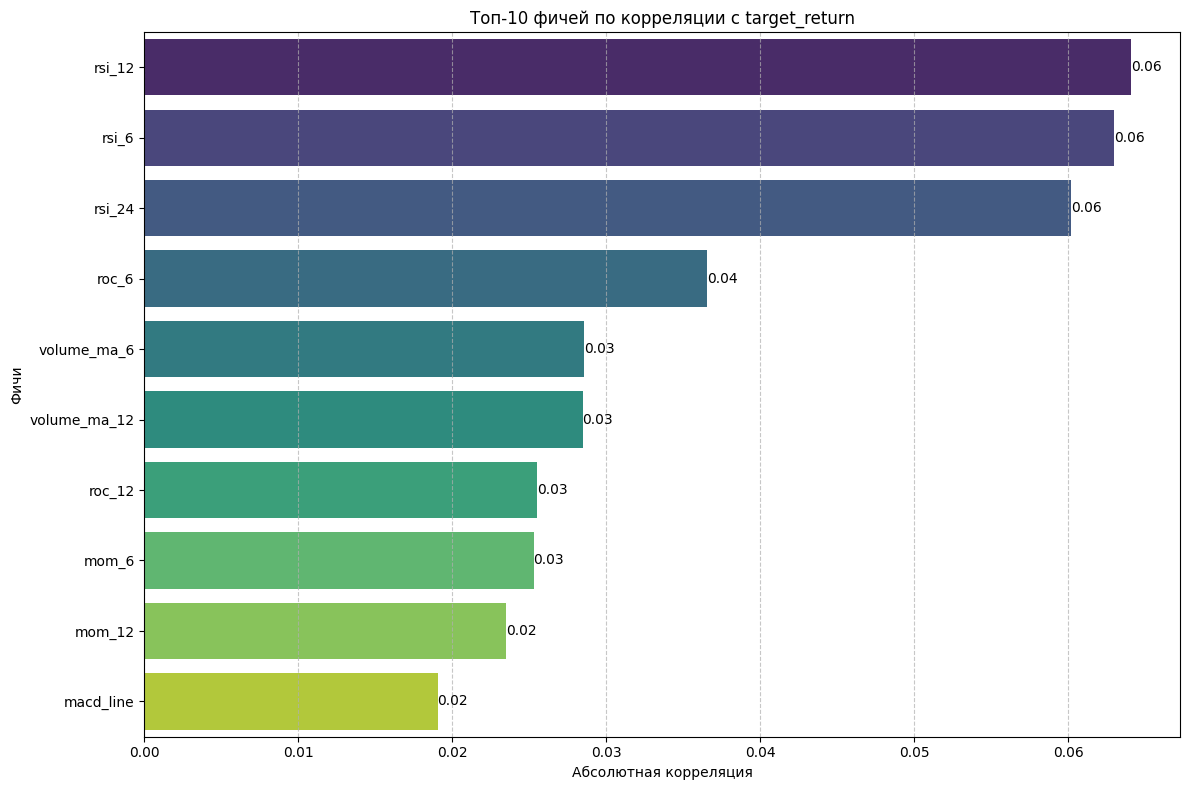

In [339]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def select_features_by_correlation(df, target_col='target_return', top_n=10, figsize=(12, 8)):
    """
    Отбирает топ-N фичей по корреляции с целевой переменной и визуализирует результат.
    
    Параметры:
    ----------
    df : pd.DataFrame
        DataFrame с фичами и целевой переменной
    target_col : str, optional
        Название целевой колонки (по умолчанию 'target_return')
    top_n : int, optional
        Количество топовых фичей для отбора (по умолчанию 10)
    figsize : tuple, optional
        Размер графика (по умолчанию (12, 8))
    
    Возвращает:
    -----------
    tuple: (top_features, corr_matrix)
        top_features: список названий топ-N фичей
        corr_matrix: матрица корреляции для топ-N фичей
    """
    
    # Проверка наличия целевой переменной
    if target_col not in df.columns:
        raise ValueError(f"Целевая переменная '{target_col}' не найдена в DataFrame")
    
    # Вычисляем матрицу корреляции
    corr_matrix = df.corr(numeric_only=True)
    
    # Получаем корреляции с целевой переменной
    target_corr = corr_matrix[target_col].abs().sort_values(ascending=False)
    
    # Исключаем саму целевую переменную
    target_corr = target_corr[target_corr.index != target_col]
    
    # Выбираем топ-N фичей
    top_features = target_corr.head(top_n).index.tolist()
    
    # Визуализация
    plt.figure(figsize=figsize)
    sns.barplot(x=target_corr.head(top_n).values, 
                y=target_corr.head(top_n).index,
                palette='viridis')
    
    plt.title(f'Топ-{top_n} фичей по корреляции с {target_col}')
    plt.xlabel('Абсолютная корреляция')
    plt.ylabel('Фичи')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Добавляем значения корреляции на график
    for i, v in enumerate(target_corr.head(top_n).values):
        plt.text(v, i, f"{v:.2f}", color='black', va='center')
    
    plt.tight_layout()
    plt.show()
    
    # Возвращаем топовые фичи и матрицу корреляции для топ-N фичей
    return top_features, corr_matrix.loc[top_features, top_features]


top_features, corr_matrix = select_features_by_correlation(final_df, top_n=10)

In [345]:
#df_final = final_df[top_features+['symbol', 'Date', 'target_return']]
#df_final.to_csv("data/df_top_10.csv", index=0)
final_df = final_df.rename(columns={"Date": "ds", "target_return": "y"})
final_df.to_csv("data/df_final.csv", index=0)
final_df["ds"] = pd.to_datetime(final_df["ds"])

In [119]:
# Сatboost

In [346]:
fill  = final_df.ds.nunique()
mask = final_df.groupby('symbol')["ds"].transform('count') == fill
filtered_df = final_df[mask]

In [347]:
filtered_df.head()

,ds,symbol,ema_3,ema_6,ema_12,ema_24,rsi_6,rsi_12,rsi_24,macd_line,...,atr_6,atr_12,obv,volume_ma_6,volume_ma_12,mom_6,mom_12,roc_6,roc_12,y
0,2017-09-01,A,54.574602,51.862790,48.104412,42.399917,82.336097,76.871746,72.980363,3.758378,...,3.759026,3.819492,291521000.0,4.187105e+07,4.121588e+07,13.172077,14.507324,30.880926,35.110401,0.010338
1,2017-10-01,A,55.489123,53.160177,49.381217,43.520215,83.212641,77.484036,73.451111,3.778960,...,3.566018,3.706080,323835200.0,3.973427e+07,4.101632e+07,10.423946,11.473469,22.670759,25.536221,0.082455
2,2017-11-01,A,58.271774,55.415676,51.177095,44.922952,88.656003,81.734742,76.843446,4.238581,...,4.014873,3.941372,367257800.0,4.044533e+07,4.086892e+07,12.887009,17.179554,26.754619,39.155794,-0.008035
3,2017-12-01,A,59.417822,56.886589,52.621214,46.174225,85.160838,79.996964,75.777735,4.265374,...,3.773198,3.815529,339128000.0,3.831862e+07,3.997438e+07,10.922329,16.586262,22.002397,37.715243,0.059657
4,2018-01-01,A,61.797389,58.969551,54.399021,47.614444,88.995336,82.915524,78.110847,4.570530,...,3.823861,3.839255,370600500.0,3.817193e+07,3.949186e+07,12.360252,23.385624,23.853799,57.329885,0.019883


import itertools
import optuna
from prophet import Prophet
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from tqdm import tqdm
from catboost import CatBoostRegressor
import pandas as pd
from datetime import datetime, timedelta
def walk_forward_validation_by_symbol(df, model_type='catboost', initial_train_end='2024-01-01',
                                     val_end='2024-12-31', forecast_window=3, 
                                     params_catboost={"n_estimators": 500, "verbose": 0},
                                     save_model=0):
    """
    Реализация скользящего окна валидации с отбором символов по R2 > 0
    
    Параметры:
    - df: DataFrame с данными
    - model_type: 'catboost'
    - initial_train_end: дата окончания начального обучающего набора
    - val_end: дата окончания валидационного периода
    - forecast_window: количество месяцев для прогнозирования (по умолчанию 3)
    - params_catboost: параметры для CatBoost
    - save_model: сохранять ли модель (0 - нет, 1 - да)
    
    Возвращает:
    - results_avg: DataFrame с усредненными метриками
    - results_detailed: DataFrame с детализированными метриками
    - final_predictions: DataFrame с предсказаниями для последних 3 месяцев
    """
    
    symbols = df['symbol'].unique()
    results_avg = {}
    results_detailed = []
    final_predictions = []
    
    # 1. Первоначальное обучение на всех данных кроме последних 6 месяцев
    initial_val_start = pd.to_datetime(val_end) - pd.DateOffset(months=6)
    initial_train = df[df['ds'] < initial_val_start]
    
    # 2. Валидация на следующих 3 месяцах и отбор символов с R2 > 0
    initial_val_end = initial_val_start + pd.DateOffset(months=3)
    initial_val = df[(df['ds'] >= initial_val_start) & (df['ds'] < initial_val_end)]
    
    selected_symbols = set()
    
    for symbol in tqdm(symbols, desc="Initial model training and validation"):
        symbol_train = initial_train[initial_train['symbol'] == symbol]
        symbol_val = initial_val[initial_val['symbol'] == symbol]
        
        if len(symbol_train) == 0 or len(symbol_val) == 0:
            continue
            
        try:
            # Обучение модели
            model = CatBoostRegressor(**params_catboost)
            X_train = symbol_train.drop(["symbol", "y", "ds"], axis=1)
            model.fit(X_train, symbol_train["y"])
            
            # Валидация
            X_val = symbol_val.drop(["symbol", "y", "ds"], axis=1)
            val_pred = model.predict(X_val)
            
            # Расчет R2
            r2 = r2_score(symbol_val['y'], val_pred)
            
            if r2 > 0:
                selected_symbols.add(symbol)
                if save_model == 1:
                    model_path = f"models_m/catboost_{symbol}_initial.cbm"
                    model.save_model(str(model_path))
                
                # Сохранение метрик
                val_metrics = {
                    'symbol': symbol,
                    'period_type': 'initial_validation',
                    'date_from': initial_val_start.strftime('%Y-%m-%d'),
                    'date_to': (initial_val_end - timedelta(days=1)).strftime('%Y-%m-%d'),
                    'MAE': mean_absolute_error(symbol_val['y'], val_pred),
                    'RMSE': mean_squared_error(symbol_val['y'], val_pred, squared=False),
                    'MAPE': mean_absolute_percentage_error(symbol_val['y'], val_pred),
                    'R2': r2,
                    'model_date': initial_val_start.strftime('%Y-%m-%d')
                }
                results_detailed.append(val_metrics)
                
        except Exception as e:
            print(f"Ошибка для символа {symbol}: {str(e)}")
    
    print(f"Отобрано символов с R2 > 0: {len(selected_symbols)}")
    
    # 3. Обучение на новых данных (добавляем 3 месяца) для отобранных символов
    new_train_end = initial_val_end
    new_val_start = new_train_end
    new_val_end = new_val_start + pd.DateOffset(months=3)
    
    for symbol in tqdm(selected_symbols, desc="Training on extended data"):
        # Новый обучающий набор (включая предыдущие 3 месяца валидации)
        new_train = df[(df['symbol'] == symbol) & (df['ds'] < new_train_end)]
        new_val = df[(df['symbol'] == symbol) & 
                    (df['ds'] >= new_val_start) & 
                    (df['ds'] < new_val_end)]
        
        if len(new_train) == 0 or len(new_val) == 0:
            continue
            
        try:
            # Обучение модели
            model = CatBoostRegressor(**params_catboost)
            X_train = new_train.drop(["symbol", "y", "ds"], axis=1)
            model.fit(X_train, new_train["y"])
            
            # Валидация
            X_val = new_val.drop(["symbol", "y", "ds"], axis=1)
            val_pred = model.predict(X_val)
            
            if save_model == 1:
                model_path = f"models_m/catboost_{symbol}_extended.cbm"
                model.save_model(str(model_path))
            
            # Сохранение метрик
            val_metrics = {
                'symbol': symbol,
                'period_type': 'extended_validation',
                'date_from': new_val_start.strftime('%Y-%m-%d'),
                'date_to': (new_val_end - timedelta(days=1)).strftime('%Y-%m-%d'),
                'MAE': mean_absolute_error(new_val['y'], val_pred),
                'RMSE': mean_squared_error(new_val['y'], val_pred, squared=False),
                'MAPE': mean_absolute_percentage_error(new_val['y'], val_pred),
                'R2': r2_score(new_val['y'], val_pred),
                'model_date': new_train_end.strftime('%Y-%m-%d')
            }
            results_detailed.append(val_metrics)
            
        except Exception as e:
            print(f"Ошибка для символа {symbol}: {str(e)}")
    
    # 4. Предсказание на последних 3 месяцах для отобранных символов
    
    final_test_start = new_val_start
    final_test_end = pd.to_datetime(new_val_end)
    print(final_test_start, final_test_end)
    
    for symbol in tqdm(selected_symbols, desc="Final predictions"):
        final_test = df[(df['symbol'] == symbol) & 
                       (df['ds'] >= final_test_start) & 
                       (df['ds'] <= final_test_end)]
        
        if len(final_test) == 0:
            continue
            
        try:
            # Загрузка последней модели
            model_path = f"models_m/catboost_{symbol}_extended.cbm"
            model = CatBoostRegressor()
            model.load_model(model_path)
            
            # Предсказание
            X_test = final_test.drop(["symbol", "y", "ds"], axis=1)
            test_pred = model.predict(X_test)
            
            # Сохранение предсказаний
            pred_df = final_test[['symbol', 'ds']].copy()
            pred_df['prediction'] = test_pred
            pred_df['actual'] = final_test['y']
            final_predictions.append(pred_df)
            
            # Расчет метрик
            test_metrics = {
                'symbol': symbol,
                'period_type': 'final_test',
                'date_from': final_test_start.strftime('%Y-%m-%d'),
                'date_to': final_test_end.strftime('%Y-%m-%d'),
                'MAE': mean_absolute_error(final_test['y'], test_pred),
                'RMSE': mean_squared_error(final_test['y'], test_pred, squared=False),
                'MAPE': mean_absolute_percentage_error(final_test['y'], test_pred),
                'R2': r2_score(final_test['y'], test_pred),
                'model_date': new_train_end.strftime('%Y-%m-%d')
            }
            results_detailed.append(test_metrics)
            
        except Exception as e:
            print(f"Ошибка для символа {symbol}: {str(e)}")
    
    # Создание DataFrame с детализированными метриками
    df_results_detailed = pd.DataFrame(results_detailed)
    
    # Агрегация метрик по символам
    if len(results_detailed) > 0:
        df_results_avg = df_results_detailed.groupby('symbol').agg({
            'MAE': 'mean',
            'RMSE': 'mean',
            'MAPE': 'mean',
            'R2': 'mean'
        })
    else:
        df_results_avg = pd.DataFrame()
    
    # Объединение всех предсказаний
    if len(final_predictions) > 0:
        df_final_predictions = pd.concat(final_predictions)
    else:
        df_final_predictions = pd.DataFrame()
    
    return df_results_avg, df_results_detailed, df_final_predictions

In [ ]:
fii

In [593]:
train_end_date='2023-09-01'
val_start_date='2024-01-01'
val_end_date='2024-06-30'
train_data = filtered_df[(filtered_df['ds'] <= train_end_date)]
val_data = filtered_df[(filtered_df['ds'] >= val_start_date) & 
                       (filtered_df['ds'] <= val_end_date)]

X_train = train_data.drop(["symbol", "y", "ds"], axis=1)
y_train = train_data["y"]

# Валидация
X_val = val_data.drop(["symbol", "y", "ds"], axis=1)
y_val = val_data["y"]

In [594]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression

# Генерация синтетических данных (замените на свои данные)
def objective(trial):
    # Определяем гиперпараметры для оптимизации
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-5, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'verbose': False,  # Отключаем вывод в процессе обучения
    }

    # Инициализация и обучение модели
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train)

    # Предсказание и оценка качества
    y_pred = model.predict(X_val)
    r2 = r2_score(y_val, y_pred)

    return r2  # Optuna максимизирует метрику (чем выше R2, тем лучше)

# Оптимизация
study = optuna.create_study(direction='maximize')  # Максимизируем R2-score
study.optimize(objective, n_trials=100)  # Количество итераций оптимизации

# Вывод результатов
print("Лучшие гиперпараметры:", study.best_params)
print("Лучший R2-score:", study.best_value)

[I 2025-05-21 18:14:59,990] A new study created in memory with name: no-name-5a25815d-baaf-4e63-b6bb-13db13073591
[I 2025-05-21 18:15:08,706] Trial 0 finished with value: -0.035103611503148 and parameters: {'iterations': 978, 'learning_rate': 0.011888974101017465, 'depth': 5, 'l2_leaf_reg': 2.493355618206058, 'random_strength': 0.855937502670094, 'bagging_temperature': 0.08465280482309667, 'border_count': 166}. Best is trial 0 with value: -0.035103611503148.
[I 2025-05-21 18:15:13,168] Trial 1 finished with value: -0.12825161865087353 and parameters: {'iterations': 652, 'learning_rate': 0.24344831447535992, 'depth': 6, 'l2_leaf_reg': 0.0013809381157918635, 'random_strength': 0.003893749596752636, 'bagging_temperature': 0.0927970799601574, 'border_count': 126}. Best is trial 0 with value: -0.035103611503148.
[I 2025-05-21 18:15:20,676] Trial 2 finished with value: -0.03987108899993297 and parameters: {'iterations': 568, 'learning_rate': 0.010098721190752362, 'depth': 9, 'l2_leaf_reg': 0

Лучшие гиперпараметры: {'iterations': 441, 'learning_rate': 0.010081157847095006, 'depth': 5, 'l2_leaf_reg': 0.005777726350574567, 'random_strength': 9.558964117512318, 'bagging_temperature': 0.3692870675294961, 'border_count': 246}
Лучший R2-score: -0.025862064016070496


In [595]:
study.best_params

{'iterations': 441,
 'learning_rate': 0.010081157847095006,
 'depth': 5,
 'l2_leaf_reg': 0.005777726350574567,
 'random_strength': 9.558964117512318,
 'bagging_temperature': 0.3692870675294961,
 'border_count': 246}

In [ ]:
params = {'iterations': 441,
 'learning_rate': 0.010081157847095006,
 'depth': 5,
 'l2_leaf_reg': 0.005777726350574567,
 'random_strength': 9.558964117512318,
 'bagging_temperature': 0.3692870675294961,
 'border_count': 246}

In [349]:
def walk_forward_validation_by_symbol(df, 
                                    train_end_date='2024-06-01',
                                    val_start_date='2024-07-01',
                                    val_end_date='2024-09-30',
                                    test_start_date='2024-10-01',
                                    test_end_date='2024-12-31',
                                    model_type='catboost',
                                    params_catboost={"n_estimators": 500, "verbose": 0},
                                    save_model=0):
    """
    Реализация валидации с явным указанием дат и расчетом feature importance
    
    Параметры:
    - df: DataFrame с данными (должен содержать колонки: symbol, ds, y)
    - train_end_date: дата окончания обучения (включительно)
    - val_start_date: дата начала валидации
    - val_end_date: дата окончания валидации (включительно)
    - test_start_date: дата начала тестирования
    - test_end_date: дата окончания тестирования (включительно)
    - model_type: тип модели (только 'catboost')
    - params_catboost: параметры CatBoost
    - save_model: сохранять модели (1 - да, 0 - нет)
    
    Возвращает:
    - df_results_avg: средние метрики по символам
    - df_results_detailed: детальные метрики
    - df_final_predictions: предсказания на тестовом периоде
    - df_feature_importance: важность фичей по отобранным символам
    """
    
    # Преобразование дат
    train_end_date = pd.to_datetime(train_end_date)
    val_start_date = pd.to_datetime(val_start_date)
    val_end_date = pd.to_datetime(val_end_date)
    test_start_date = pd.to_datetime(test_start_date)
    test_end_date = pd.to_datetime(test_end_date)
    
    # Проверка корректности дат
    if not (train_end_date < val_start_date <= val_end_date < test_start_date <= test_end_date):
        raise ValueError("Некорректные даты. Должно быть: train_end < val_start <= val_end < test_start <= test_end")
    
    symbols = df['symbol'].unique()
    results_detailed = []
    final_predictions = []
    feature_importances = []
    
    # 1. Обучение на train периоде и валидация
    selected_symbols = set()
    
    for symbol in tqdm(symbols, desc="Initial training and validation"):
        try:
            # Подготовка данных
            train_data = df[(df['symbol'] == symbol) & (df['ds'] <= train_end_date)]
            val_data = df[(df['symbol'] == symbol) & 
                         (df['ds'] >= val_start_date) & 
                         (df['ds'] <= val_end_date)]
            
            if len(train_data) < 10 or len(val_data) < 5:  # Минимальные требования
                continue
                
            # Обучение модели
            model = CatBoostRegressor(**params_catboost)
            X_train = train_data.drop(["symbol", "y", "ds"], axis=1)
            y_train = train_data["y"]
            
            model.fit(X_train, y_train)
            
            # Валидация
            X_val = val_data.drop(["symbol", "y", "ds"], axis=1)
            y_val = val_data["y"]
            val_pred = model.predict(X_val)
            
            # Проверка R2
            r2 = r2_score(y_val, val_pred)
            
            if r2 > 0:
                selected_symbols.add(symbol)
                
                # Сохранение модели
                if save_model:
                    model_path = f"models/catboost_{symbol}.cbm"
                    model.save_model(model_path)
                
                # Сохранение метрик
                results_detailed.append({
                    'symbol': symbol,
                    'period': 'validation',
                    'date_from': val_start_date.strftime('%Y-%m-%d'),
                    'date_to': val_end_date.strftime('%Y-%m-%d'),
                    'MAE': mean_absolute_error(y_val, val_pred),
                    'RMSE': mean_squared_error(y_val, val_pred, squared=False),
                    'MAPE': mean_absolute_percentage_error(y_val, val_pred),
                    'R2': r2
                })
                
                # Сохранение важности фичей
                feature_importance = model.get_feature_importance()
                feature_names = X_train.columns.tolist()
                
                for name, importance in zip(feature_names, feature_importance):
                    feature_importances.append({
                        'symbol': symbol,
                        'feature': name,
                        'importance': importance
                    })
                
        except Exception as e:
            print(f"Ошибка для {symbol}: {str(e)}")
    
    print(f"\nОтобрано символов с R2 > 0: {len(selected_symbols)}")
    
    # 2. Переобучение на данных до val_end_date и тестирование
    for symbol in tqdm(selected_symbols, desc="Final training and testing"):
        try:
            # Подготовка данных для переобучения
            full_train_data = df[(df['symbol'] == symbol) & (df['ds'] <= val_end_date)]
            test_data = df[(df['symbol'] == symbol) & 
                          (df['ds'] >= test_start_date) & 
                          (df['ds'] <= test_end_date)]
            
            if len(full_train_data) == 0 or len(test_data) == 0:
                continue
                
            # Переобучение модели
            model = CatBoostRegressor(**params_catboost)
            X_train_full = full_train_data.drop(["symbol", "y", "ds"], axis=1)
            y_train_full = full_train_data["y"]
            
            model.fit(X_train_full, y_train_full)
            
            # Тестирование
            X_test = test_data.drop(["symbol", "y", "ds"], axis=1)
            y_test = test_data["y"]
            test_pred = model.predict(X_test)
            
            # Сохранение предсказаний
            pred_df = test_data[['symbol', 'ds', 'y']].copy()
            pred_df['prediction'] = test_pred
            final_predictions.append(pred_df)
            
            # Сохранение метрик тестирования
            results_detailed.append({
                'symbol': symbol,
                'period': 'testing',
                'date_from': test_start_date.strftime('%Y-%m-%d'),
                'date_to': test_end_date.strftime('%Y-%m-%d'),
                'MAE': mean_absolute_error(y_test, test_pred),
                'RMSE': mean_squared_error(y_test, test_pred, squared=False),
                'MAPE': mean_absolute_percentage_error(y_test, test_pred),
                'R2': r2_score(y_test, test_pred)
            })
            
        except Exception as e:
            print(f"Ошибка для {symbol}: {str(e)}")
    
    # Формирование результатов
    df_results_detailed = pd.DataFrame(results_detailed)
    
    # Усредненные метрики
    if not df_results_detailed.empty:
        df_results_avg = df_results_detailed.groupby('symbol').mean(numeric_only=True)
    else:
        df_results_avg = pd.DataFrame()
    
    # Предсказания
    if len(final_predictions) > 0:
        df_final_predictions = pd.concat(final_predictions)
    else:
        df_final_predictions = pd.DataFrame()
    
    # Важность фичей
    if len(feature_importances) > 0:
        df_feature_importance = pd.DataFrame(feature_importances)
        # Средняя важность фичей по отобранным символам
        df_feature_importance_avg = df_feature_importance.groupby('feature')['importance'].mean().reset_index()
        df_feature_importance_avg = df_feature_importance_avg.sort_values('importance', ascending=False)
    else:
        df_feature_importance_avg = pd.DataFrame()
    
    return df_results_avg, df_results_detailed, df_final_predictions, df_feature_importance_avg

In [ ]:
    train_years=('2015-01-01', '2020-12-31'),  # 6 лет обучения
    val_years=('2021-01-01', '2022-12-31'),    # 2 года валидации
    test_years=('2023-01-01', '2023-12-31'),   # 1 года тестирования

In [592]:
detailed_metrics[detailed_metrics.period == "validation"].describe()

,MAE,RMSE,MAPE,R2
count,164.000000,164.000000,164.000000,164.000000
mean,0.060881,0.072565,1.558327,0.209356
std,0.027959,0.032249,1.653526,0.155972
min,0.014411,0.017652,0.408500,0.006299
25%,0.038646,0.046910,0.864161,0.073428
50%,0.056258,0.070024,1.056044,0.173174
75%,0.079533,0.093032,1.551948,0.308961
max,0.133745,0.166914,14.671208,0.786579


In [580]:
avg_metrics, detailed_metrics, predictions, feature_importance = walk_forward_validation_by_symbol(
    filtered_df,
    train_end_date='2023-09-01',
    val_start_date='2024-01-01',
    val_end_date='2024-06-30',
    test_start_date='2024-07-01',
    test_end_date='2024-10-31',
    params_catboost=params,
    save_model=1
)

# Вывод результатов
print("Средние метрики:")
print(avg_metrics.head())

print("\nВажные фичи:")
print(feature_importance.head(10))

print("\nПример предсказаний:")
print(predictions.head())

Initial training and validation: 100%|██████████| 462/462 [02:36<00:00,  2.96it/s]



Отобрано символов с R2 > 0: 164


Final training and testing: 100%|██████████| 164/164 [00:57<00:00,  2.88it/s]

Средние метрики:
             MAE      RMSE      MAPE        R2
symbol                                        
A       0.058852  0.076191  1.292852 -0.242663
ABT     0.033286  0.041197  0.780777  0.150563
ACN     0.065213  0.072785  0.951362 -0.084476
ADBE    0.091329  0.118700  1.649590 -0.401731
ADI     0.051739  0.069975  2.087340 -0.043660

Важные фичи:
        feature  importance
11          obv    6.924523
15       rsi_24    5.945175
16        rsi_6    5.878944
14       rsi_12    5.801983
12       roc_12    5.764209
4         ema_3    5.746180
18  volume_ma_6    5.546727
2        ema_12    5.449563
13        roc_6    5.442667
3        ema_24    5.374140

Пример предсказаний:
     symbol         ds         y  prediction
4632    BAX 2024-07-01 -0.155561   -0.024621
4633    BAX 2024-08-01 -0.010187   -0.014526
4634    BAX 2024-09-01  0.070852    0.025913
4635    BAX 2024-10-01  0.059185   -0.008336
6361    CAH 2024-07-01 -0.036588    0.049678


In [575]:
feature_importance.shape[0]

19

C:\Users\user\AppData\Local\Temp\ipykernel_16712\3305941265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')


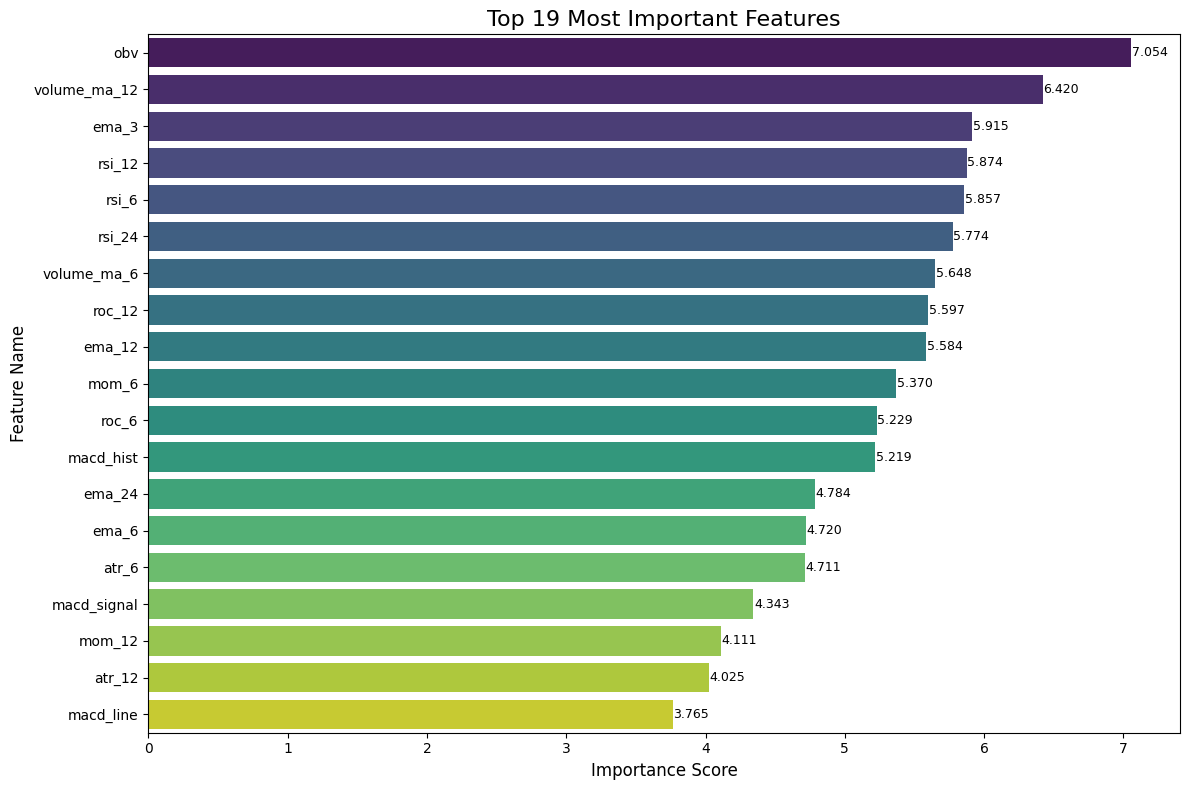

In [576]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(feature_importance_df, top_n=feature_importance.shape[0]):
    """
    Визуализация важности фичей
    
    Параметры:
    - feature_importance_df: DataFrame с колонками 'feature' и 'importance'
    - top_n: количество топовых фичей для отображения
    """
    if feature_importance_df.empty:
        print("Нет данных о важности фичей")
        return
    
    # Сортировка и выбор топ-N фичей
    top_features = feature_importance_df.sort_values('importance', ascending=False).head(top_n)
    
    # Создание графика
    plt.figure(figsize=(12, 8))
    sns.barplot(x='importance', y='feature', data=top_features, palette='viridis')
    
    # Настройка оформления
    plt.title(f'Top {top_n} Most Important Features', fontsize=16)
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    
    # Добавление значений на график
    for i, (_, row) in enumerate(top_features.iterrows()):
        plt.text(row['importance'] + 0.005, i, f"{row['importance']:.3f}", 
                va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
plot_feature_importance(feature_importance, top_n=19)

In [563]:
#df = pd.read_csv("final_predictions.csv", index_col=0)
predictions["ds"] = pd.to_datetime(predictions['ds'])
df_pivot = predictions.pivot(index='ds', columns='symbol', values='prediction')

df_pivot.index = pd.to_datetime(df_pivot.index)
df_pivot.head()

symbol,A,AAL,ABBV,AEE,AEP,AFL,AIG,AJG,ALL,ALLE,...,WAT,WBD,WDC,WEC,WFC,WM,WTW,XEL,XRAY,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2023-07-01,0.001422,0.052745,0.017155,-0.017025,-0.003883,0.059208,0.018239,-0.004644,0.007087,0.011188,...,0.010019,0.043838,-0.024185,-0.005805,0.049029,-0.010993,-0.016833,-0.003246,0.050488,0.012110
2023-08-01,0.060790,0.010106,0.067719,0.040334,0.070130,0.082645,0.023612,0.018535,0.049432,0.031269,...,0.100678,0.036961,-0.012490,0.057280,0.021919,0.023231,-0.025140,0.024936,0.052163,0.068546
2023-09-01,0.064905,-0.002168,0.076824,0.043461,0.076497,0.065089,-0.020268,-0.014398,0.048708,-0.006410,...,0.101656,0.018340,0.005668,0.038269,0.009033,-0.013508,-0.032111,0.042210,0.046283,0.022512
2023-10-01,0.076716,-0.003248,0.028210,0.034267,0.076567,0.058077,-0.040846,-0.012333,0.031713,-0.001742,...,0.099975,0.022726,0.006930,0.038324,-0.016497,0.006059,0.004216,0.039703,0.047113,0.056572
2023-11-01,0.090645,-0.017201,0.014466,0.038810,0.062013,0.046919,-0.033754,-0.027339,0.045804,0.002745,...,0.089611,0.030519,-0.029678,0.056943,0.007595,0.019526,-0.002347,0.059817,0.040576,0.064796


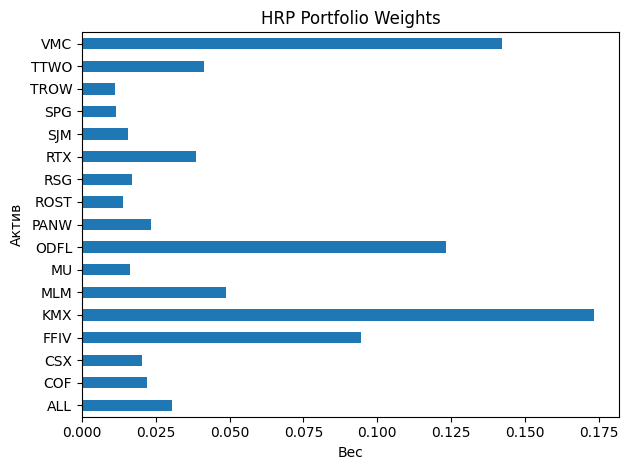

In [567]:
from pypfopt import risk_models, expected_returns
from pypfopt.hierarchical_portfolio import HRPOpt# Создаем объект HRP
hrp = HRPOpt(df_pivot)

# Кластеризация + вычисление весов
weights = hrp.optimize()


# Преобразуем в DataFrame
weights_df = pd.DataFrame.from_dict(weights, orient='index', columns=['Weight'])

# Фильтруем только те актива с ненулевым весом
weights_df = weights_df[weights_df['Weight'] > 0.01]

# Построим график
weights_df.plot(kind='barh', title='HRP Portfolio Weights', legend=False)
plt.xlabel('Вес')
plt.ylabel('Актив')
plt.tight_layout()
plt.show()

In [ ]:
04/08, 08/12, 01/04

SyntaxError: invalid syntax (197546262.py, line 1)

In [559]:
returns

Ticker,BWA,CFG,COP,EQIX,GNRC,HOLX,LHX,OXY,ROL,TAP,TSLA
Date,,,,,,,,,,,
2025-01-01,0.006687,0.087066,-0.003428,-0.031000,-0.036891,0.000694,0.008227,-0.051576,0.067961,-0.037942,0.001882
2025-02-01,-0.066771,-0.029410,0.003238,-0.009894,-0.088261,-0.121292,-0.027829,0.046945,0.058384,0.119452,-0.275877


In [560]:
weights_df

,Weight
BWA,0.012391
CFG,0.039687
COP,0.016415
EQIX,0.014942
GNRC,0.015621
HOLX,0.013076
LHX,0.255277
OXY,0.024102
ROL,0.388133
TAP,0.025209


In [571]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Пример портфеля (активы и их веса
# Безрисковая ставка (годовая)
risk_free_rate = 0.02  

# Даты для загрузки данных
start_date = "2024-01-01"
end_date = "2024-04-01"

def months_between_pandas(start_date, end_date):
    start = pd.to_datetime(start_date)
    end = pd.to_datetime(end_date)
    return (end.year - start.year) * 12 + (end.month - start.month)

# Пример
cnt_months = months_between_pandas(start_date, end_date)

# Загружаем цены активов
prices = yf.download(weights_df.index.to_list(), start=start_date, end=end_date, interval="1mo")["Close"]

# Месячные доходности (можно изменить на недельные/дневные)
returns = prices.pct_change().dropna()

# Взвешенная доходность портфеля
portfolio_returns = (returns * weights_df["Weight"].values).sum(axis=1)

# Доходность рынка (S&P 500 для расчёта Beta и Alpha)
market_returns = yf.download("^GSPC", start=start_date, end=end_date, interval="1mo")["Close"].pct_change().dropna()

# Объединяем в один DataFrame
combined_returns = pd.DataFrame({
    "portfolio": portfolio_returns.values,
    "market": market_returns['^GSPC'].values
}).dropna()

def calculate_sharpe(returns, risk_free_rate=0.02, periods_per_year=12):
    excess_returns = returns - (risk_free_rate / periods_per_year)
    annualized_return = excess_returns.mean() * periods_per_year
    annualized_volatility = returns.std() * np.sqrt(periods_per_year)
    sharpe_ratio = annualized_return / annualized_volatility
    return sharpe_ratio

sharpe = calculate_sharpe(combined_returns["portfolio"], risk_free_rate)
print(f"Sharpe Ratio: {sharpe:.4f}")

X = sm.add_constant(combined_returns["market"])  # Добавляем константу
y = combined_returns["portfolio"]

model = sm.OLS(y, X).fit()
beta = model.params["market"]
alpha = model.params["const"] * 12  # Годовой Alpha

print(f"Beta: {beta:.4f}")
print(f"Alpha: {alpha:.6f} (или {alpha*100:.4f}%)")

[*********************100%***********************]  17 of 17 completed
[*********************100%***********************]  1 of 1 completed

Sharpe Ratio: 8.8216
Beta: 1.3749
Alpha: -0.047511 (или -4.7511%)


04/08
Sharpe Ratio: 2.4228

Beta: 0.8448

Alpha: 0.042762 (или 4.2762%)

08/12

Sharpe Ratio: 1.3008
Beta: -0.3917
Alpha: 0.191291 (или 19.1291%)


12/03

Sharpe Ratio: 2.9785
Beta: 0.5936
Alpha: 0.153175 (или 15.3175%)

1. Sharpe Ratio = 1.77
Что это значит?

Превосходный результат (значительно выше 1.0).

Портфель генерирует 1.77 единиц избыточной доходности на единицу риска (волатильности).

Для сравнения:

Sharpe > 2 — выдающийся результат (редкость на длительных горизонтах).

Sharpe 1.5–2 — очень сильная стратегия.

Sharpe < 1 — требует оптимизации.

Возможные причины:

Удачный выбор активов с низкой корреляцией.

Возможно, в портфеле есть защитные активы (золото, облигации), снижающие волатильность.

Если период расчёта короткий (например, 2023 год), результат может быть завышен из-за рыночного роста.

Риски:

Результат может быть неустойчивым на длительных периодах.

2. Beta = 0.52
Что это значит?

Портфель вдвое менее волатилен, чем рынок (S&P 500).

Если рынок упадёт на 10%, ваш портфель просядет примерно на 5.2%.

Если рынок вырастет на 10%, портфель вырастет на ~5.2%.

Преимущества:

Низкая чувствительность к рыночным шокам (хорошо для консервативных инвесторов).

Подходит для стратегий с защитой от падений.

Недостатки:

В bullish-рынки (как 2023–2024) портфель может отставать от индекса.

3. Alpha = 16.01% (годовых)
Что это значит?

После учёта рыночного риска (Beta) портфель превышает ожидаемую доходность на 16% в год.

Это исключительно высокий показатель, указывающий на:

Удачный stock-picking (выбор акций, обыгравших рынок).

Эффективную стратегию (например, факторное инвестирование).

Низкую корреляцию с рынком (например, за счёт альтернативных активов).

Проверьте:

Нет ли переобучения (overfitting) — если Alpha рассчитана на коротком периоде, она может быть завышена.

Учтены ли все издержки (комиссии, налоги).

Общий вывод
✅ Сильные стороны:

Выдающаяся доходность на единицу риска (Sharpe 1.77).

Защищённость от рыночных падений (Beta 0.52).

Способность обыгрывать рынок (Alpha 16%).

⚠️ Риски:

Возможна неустойчивость результатов на длительных периодах.

В растущих рынках может отставать от индекса (из-за низкой Beta).

Рекомендации
Проверить устойчивость стратегии на данных за 5–10 лет.

Добавить немного агрессивных активов (например, Nasdaq-100) для роста Beta до 0.7–0.8, если хотите больше участвовать в росте рынка.

Фиксировать прибыль — такие высокие показатели редко сохраняются долго.

Пример оптимизации:

Если Beta = 0.52 кажется слишком низкой, можно добавить SPY (S&P 500 ETF) с весом 20–30%, чтобы приблизить Beta к 0.7–0.8 без резкого роста риска.

Итог: Ваш портфель выглядит эффективным и защищённым, но требует мониторинга на длительных периодах.